Classification Model - EDA  Classification

Claudia Galdamez

Goal: The goal of this is to build a model that predicts the y column (0 or 1).

In [ ]:
##Import libraries needed

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

The goal of this is to build a model that predicts the y column (0 or 1). Since the dataset has both numeric and categorical data, I need to clean it first before training a model.

In [ ]:
#Load data
df = pd.read_csv('/content/eda_classification.csv')
df.head()

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,x14,x15,x16,x17,y
0,-17.933519,Jun,6.559220,-14.452810,-4.732855,0.381673,2.563194,"($1,306.52)",-89.394348,-28.454044,-16.201298,-0.01%,0.217010,tesla,thurday,9.729891,-0.786431,small,1
1,-37.214754,July,10.774930,-15.384004,-0.077339,10.983774,-15.210206,($24.86),153.032652,-32.557736,69.675903,0.00%,-3.584908,Toyota,thur,35.727926,-0.985552,small,0
2,0.330441,Aug,-19.609972,-9.167911,2.064124,12.071688,12.506141,($110.85),-141.437276,-20.794952,55.042604,0.00%,-3.991366,bmw,wednesday,-9.283523,-3.394718,small,1
3,-13.709765,Aug,-8.011390,6.759264,1.727615,-1.768382,24.039733,($324.43),51.039653,-7.046908,-31.424419,0.01%,7.908897,Toyota,wed,-2.891882,-2.690222,small,0
4,-4.202598,May,7.076210,-26.004919,-4.269696,-3.414224,2.115989,"$1,213.37",-31.046700,19.061182,-31.525515,-0.01%,0.846719,Honda,wednesday,25.497480,3.516801,small,1


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


I loaded the data and checked the first few rows to understand the structure. There’s a mix of numerical features and categorical variables like month, car brand, and weekday. Some columns also include formatted values like currency and percentages, which will likely need to be cleaned or converted before building the model.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 19 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x0      9996 non-null   float64
 1   x1      9999 non-null   object 
 2   x2      9995 non-null   float64
 3   x3      9996 non-null   float64
 4   x4      9997 non-null   float64
 5   x5      9997 non-null   float64
 6   x6      9999 non-null   float64
 7   x7      9996 non-null   object 
 8   x8      9998 non-null   float64
 9   x9      9999 non-null   float64
 10  x10     9996 non-null   float64
 11  x11     9997 non-null   object 
 12  x12     9995 non-null   float64
 13  x13     9998 non-null   object 
 14  x14     9997 non-null   object 
 15  x15     9999 non-null   float64
 16  x16     9998 non-null   float64
 17  x17     9999 non-null   object 
 18  y       9999 non-null   int64  
dtypes: float64(12), int64(1), object(6)
memory usage: 1.4+ MB


The dataset contains 19 columns, with most stored as numeric types but 6 columns stored as objects. These object columns likely represent categorical features such as month, brand, or weekday, and some may include formatted values that need to be cleaned.

There are also small amounts of missing data across multiple columns, so those will need to be handled before modeling to avoid errors.

In [ ]:
#Summary statistics
df.describe()

,x0,x2,x3,x4,x5,x6,x8,x9,x10,x12,x15,x16,y
count,9996.000000,9995.000000,9996.000000,9997.000000,9997.000000,9999.000000,9998.000000,9999.000000,9996.000000,9995.000000,9999.000000,9998.000000,9999.000000
mean,6.501091,-3.729880,-7.335819,-0.001323,1.347141,1.214413,-4.239862,-0.297257,-22.482050,0.034517,-0.222981,-0.430020,0.491949
std,29.140034,17.237178,38.355015,3.995307,9.606695,17.352962,131.921984,37.987287,91.723733,6.065264,14.679529,2.825224,0.499960
min,-106.809919,-65.137848,-150.846091,-14.616540,-37.499530,-59.900503,-661.764937,-142.719688,-427.412374,-25.024464,-57.315771,-12.527505,0.000000
25%,-13.094564,-15.356197,-33.079854,-2.681308,-5.047927,-10.904697,-91.489340,-25.685742,-79.734745,-4.191568,-10.312554,-2.346461,0.000000
50%,6.659263,-3.825630,-7.374468,0.010637,1.217076,0.814006,-4.744892,-0.239779,-20.459860,0.154775,-0.633445,-0.415075,0.000000
75%,26.214107,7.764036,18.477979,2.635699,7.807128,12.693538,83.831778,25.459537,38.383398,4.136013,9.504719,1.448256,1.000000
max,114.823451,67.685933,127.204103,16.923269,38.624213,68.865261,476.910533,181.063340,319.592518,21.540626,57.918619,8.987513,1.000000


The summary statistics show that several numeric features have large differences between their minimum and maximum values, indicating high variability and possible skew in the data. Some features include both negative and very large positive values, which means the data is not standardized. This difference in scale could impact model performance, so applying scaling will be important to make sure that no single feature takes over the model.

In [ ]:
#Check missing values

df.isnull().sum()

,0
x0,3
x1,0
x2,4
x3,3
x4,2
x5,2
x6,0
x7,3
x8,1
x9,0


The dataset has very few missing values, with most columns only missing between 1–4 entries. Compared to the total number of rows, this is a small amount of missing data, so dropping rows would remove more data than necessary.

Because of this, imputing values (using the median for numeric features) is a better approach to keep the dataset intact.

In [ ]:
#clean formatted columns

df['x7'] = df['x7'].replace(r'[\$,()]', '', regex=True).astype(float)
df['x10'] = df['x10'].replace('%', '', regex=True).astype(float)

df.head()

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,x14,x15,x16,x17,y
0,-17.933519,Jun,6.559220,-14.452810,-4.732855,0.381673,2.563194,1306.52,-89.394348,-28.454044,-16.201298,-0.01%,0.217010,tesla,thurday,9.729891,-0.786431,small,1
1,-37.214754,July,10.774930,-15.384004,-0.077339,10.983774,-15.210206,24.86,153.032652,-32.557736,69.675903,0.00%,-3.584908,Toyota,thur,35.727926,-0.985552,small,0
2,0.330441,Aug,-19.609972,-9.167911,2.064124,12.071688,12.506141,110.85,-141.437276,-20.794952,55.042604,0.00%,-3.991366,bmw,wednesday,-9.283523,-3.394718,small,1
3,-13.709765,Aug,-8.011390,6.759264,1.727615,-1.768382,24.039733,324.43,51.039653,-7.046908,-31.424419,0.01%,7.908897,Toyota,wed,-2.891882,-2.690222,small,0
4,-4.202598,May,7.076210,-26.004919,-4.269696,-3.414224,2.115989,1213.37,-31.046700,19.061182,-31.525515,-0.01%,0.846719,Honda,wednesday,25.497480,3.516801,small,1


I removed formatting characters such as $, commas, parentheses, and % from columns and converted them to numeric types. After cleaning, these columns now contain usable numeric values instead of strings, which can be seen in the updated output.

This step is important because leaving them as object types would prevent the model from properly using those features during training.

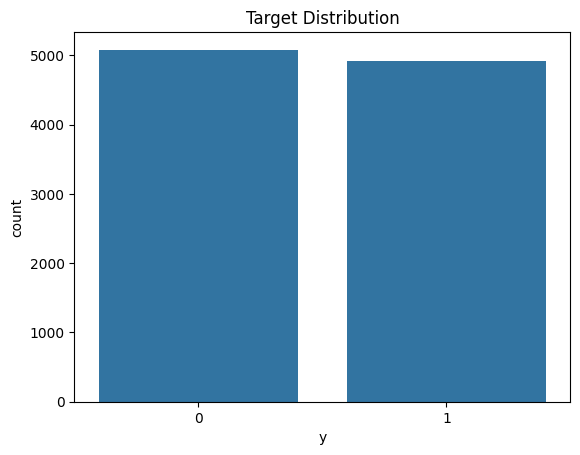

In [ ]:
#Target Distribution

sns.countplot(x='y', data=df)
plt.title("Target Distribution")
plt.show()

The target variable is fairly balanced, with a similar number of 0s and 1s. Since neither class dominates, the model won’t be biased toward predicting one class over the other.

In [ ]:
# Split X and Y
X = df.drop('y', axis=1)
y = df['y']

I separated the features from the target so the model can learn patterns from the inputs.

In [ ]:
# Column Types
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

print(num_cols)
print(cat_cols)

Index(['x0', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10', 'x12',
       'x15', 'x16'],
      dtype='object')
Index(['x1', 'x11', 'x13', 'x14', 'x17'], dtype='object')


The columns listed as object type are categorical because they store text values (like month, brand, or weekday), while the rest are numeric.

In [ ]:
# Handle missing values

X[num_cols] = X[num_cols].fillna(X[num_cols].median())
X[cat_cols] = X[cat_cols].fillna("Unknown")

Filled numeric missing values with the median to reduce the impact of outliers. Categorical missing values were filled with "Unknown" to keep all rows.

In [ ]:
#Preprocessing

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

Scaled the numbers so one column doesn’t outweigh the others, and turned the text columns into numbers for the model.

In [ ]:
# Make sure x1 is numeric
df['x1'] = pd.to_numeric(df['x1'], errors='coerce')

# Fill missing values
df['x1'] = df['x1'].fillna(df['x1'].median())

# Binning
df['x1_bin'] = pd.qcut(df['x1'], q=4, labels=False, duplicates='drop')

# Interaction feature
df['x1_x2'] = df['x1'] * df['x2']

In [ ]:
#Train/test/split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Split the data into training and testing sets to evaluate how well the model performs on unseen data.

In [ ]:
#Build/Train model

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['x0', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10', 'x12',
       'x15', 'x16'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['x1', 'x11', 'x13', 'x14', 'x17'], dtype='object'))])),
                ('classifier', LogisticRegression())])

Used logistic regression as a baseline model for this binary classification task. The pipeline ensures preprocessing and modeling are applied together.

In [ ]:
#Make predictions
y_pred = model.predict(X_test)

Generated predictions on the test data to evaluate model performance.

In [ ]:
#Model Evaluation

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

print("\n", classification_report(y_test, y_pred))

Accuracy: 0.494
Precision: 0.49463647199046484
Recall: 0.4137587238285145

               precision    recall  f1-score   support

           0       0.49      0.57      0.53       997
           1       0.49      0.41      0.45      1003

    accuracy                           0.49      2000
   macro avg       0.49      0.49      0.49      2000
weighted avg       0.49      0.49      0.49      2000



The model is performing around 49% accuracy, which is close to random guessing since the target is balanced. Precision is also around 0.49, and recall is lower for class 1 (0.41), which means the model is missing a good number of positive cases.

Overall, the model is not performing well and isn’t capturing strong patterns in the data.

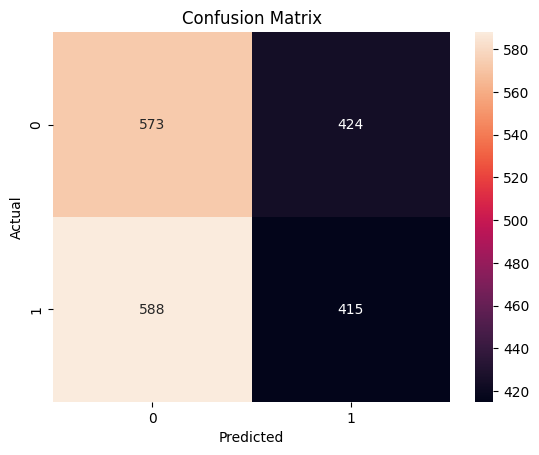

In [ ]:
#Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

The confusion matrix shows the model is making a lot of mistakes in both classes. It correctly predicted 573 zeros and 415 ones, but also misclassified 424 zeros and 588 ones.

In [ ]:
#Random Forest Model

from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)

In [ ]:
#See Results
from sklearn.metrics import classification_report, accuracy_score

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.517
              precision    recall  f1-score   support

           0       0.51      0.61      0.56       997
           1       0.52      0.43      0.47      1003

    accuracy                           0.52      2000
   macro avg       0.52      0.52      0.51      2000
weighted avg       0.52      0.52      0.51      2000



I tested Logistic Regression and Random Forest.

Both models performed close to random, with Random Forest only slightly better.

The features don’t seem to strongly predict y, so the models can’t find clear patterns.

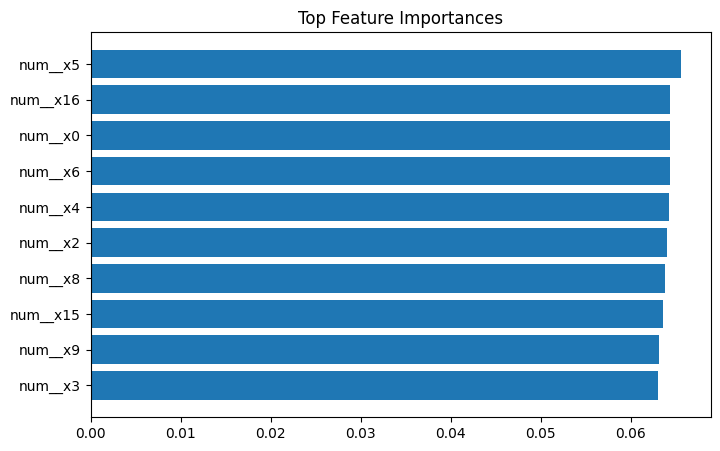

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Get feature names after preprocessing
feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Get importances
importances = rf_pipeline.named_steps['model'].feature_importances_

# Create DataFrame
feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# Plot
plt.figure(figsize=(8,5))
plt.barh(feat_imp['feature'][:10], feat_imp['importance'][:10])
plt.gca().invert_yaxis()
plt.title("Top Feature Importances")
plt.show()

I looked at which features mattered most in the model.

They all have similar importance, and none really stand out. This helps explain why the model isn’t performing well.

The features just don’t seem to strongly predict y.